### Load medical cost dataset

Load the medical cost dataset so it can be cleaned and prepared for
baseline cost modelling experiments.


In [9]:
import pandas as pd
import matplotlib.pyplot as plt



In [10]:
medical = pd.read_csv("../data/medical_cost 2.csv")

### Sanity check the dataset

Inspect the dataset dimensions and preview a few rows to confirm the data
loaded correctly and contains valid values.

In [11]:
medical.shape
medical.head()


,Id,age,sex,bmi,children,smoker,region,charges
0,1,19,female,27.900,0,yes,southwest,16884.92400
1,2,18,male,33.770,1,no,southeast,1725.55230
2,3,28,male,33.000,3,no,southeast,4449.46200
3,4,33,male,22.705,0,no,northwest,21984.47061
4,5,32,male,28.880,0,no,northwest,3866.85520


### Remove non-informative columns

Drop the ID column as it does not provide any predictive value and should
not be used as a feature in machine learning models.


In [12]:
medical = medical.drop(columns=["Id"]) # Remove unique identifier column with no predictive meaning



### Check for missing values and drop missing values

Check for missing values to determine whether additional cleaning is
required before modelling.

Remove rows with missing values to simplify baseline modelling and avoid
errors during training.



In [13]:
medical.isnull().sum()
medical = medical.dropna()

In [14]:
medical = pd.get_dummies(
    medical,
    columns=["sex", "smoker", "region"],
    drop_first=True
)
# Encode categorical variables (sex, smoker, region) into numeric features

### Visual check of feature distributions

Plot distributions of numeric features to visually inspect ranges and
confirm there are no obvious anomalies.


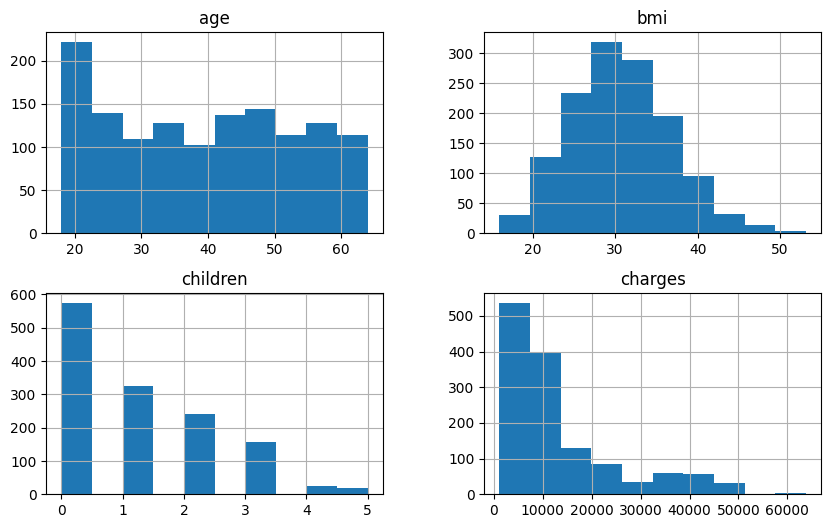

In [15]:
medical.hist(figsize=(10,6))
plt.show()


The dataset was split into input features and a target variable, where all demographic and health indicators were used to predict medical charges.

In [16]:
X = medical.drop(columns=["charges"])
y = medical["charges"]


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Separate input features and target variable
X = medical.drop(columns=["charges"])
y = medical["charges"]


# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [18]:
# Initialise and train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)


# Generate predictions on test data
predictions = model.predict(X_test)

# Evaluate model performance
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)



Mean Absolute Error: 4181.194473753654
R2 Score: 0.7835929767120722


### Summary

The medical cost dataset has been cleaned by removing non-informative
columns, handling missing values, and encoding categorical variables.
Model was trained to predict medical charges using demographic and health-related features. The dataset was split into training and testing sets to evaluate generalisation performance. Model accuracy was assessed using Mean Absolute Error (MAE) and R² score, providing an initial performance benchmark. This baseline establishes a reference point for comparing more advanced models in future iterations.

Our baseline linear regression explains about 78% of the variation in medical costs, with an average prediction error of around $4,000. This gives us a solid benchmark before experimenting with more complex models.